In [1]:
import kagglehub
import pandas as pd
from fastai.tabular.all import *

In [2]:
path = kagglehub.dataset_download(
    "aiexplorer77/gaming-vs-academic-performance",
    output_dir='./data'
)
path = Path(path)
print("Path to dataset files:", path)

Path to dataset files: data


In [3]:
base_path = Path('.')
df = pd.read_csv(path/'Gaming_Academic_Performance.csv')

In [4]:
test_df = df.sample(frac=0.1, random_state=42)
main_df = df.drop(test_df.index)

In [5]:
main_df.columns

Index(['student_id', 'age', 'gender', 'gaming_hours', 'study_hours',
       'sleep_hours', 'attendance', 'gaming_genre', 'social_activity',
       'device_usage', 'reaction_time_ms', 'addiction_score', 'stress_level',
       'grades'],
      dtype='str')

In [7]:
dls = TabularDataLoaders.from_df(
    main_df,
    path=base_path,
    y_names='grades',
    # Adding more categories for better context
    cat_names=['gaming_genre', 'gender', 'device_usage', 'stress_level'], 
    # Adding the 'heavy hitters' to continuous variables
    cont_names=[
        'age', 'gaming_hours', 'sleep_hours', 
        'study_hours', 'attendance', 'social_activity', 'addiction_score', 'reaction_time_ms'
    ],
    procs=[Categorify, FillMissing, Normalize]
)

In [8]:
dls.show_batch()

,gaming_genre,gender,device_usage,stress_level,age,gaming_hours,sleep_hours,study_hours,attendance,social_activity,addiction_score,reaction_time_ms,grades
0,Casual,Male,5.84,Medium,19.0,3.22,5.50,6.23,97.430001,2.35,8.320000,283.290008,73.260002
1,RPG,Male,8.45,Low,24.0,5.98,8.64,5.91,69.349999,4.52,13.730000,235.860002,61.360001
2,FPS,Male,10.44,Low,17.0,7.00,5.30,6.62,75.129997,4.08,17.820000,245.389999,43.220001
3,Casual,Male,4.24,Medium,16.0,1.47,4.47,3.76,82.059998,1.39,1.680000,286.630004,72.040001
4,Casual,Female,5.17,Medium,17.0,3.68,6.24,6.05,83.800003,2.86,8.050000,266.279999,72.639999
5,Casual,Female,5.93,Medium,23.0,2.66,7.65,1.16,73.250000,2.00,5.880000,300.700013,54.540001
6,RPG,Male,8.81,Low,22.0,6.62,4.63,5.15,92.089996,3.71,13.170000,238.729995,44.720001
7,Casual,Other,10.84,High,22.0,4.90,5.85,7.07,87.820000,3.07,16.030001,252.250000,69.180000
8,RPG,Male,4.57,Medium,16.0,0.80,4.09,5.40,84.480003,1.91,3.170000,317.959991,82.110001
9,RPG,Female,9.69,Low,20.0,6.42,4.48,4.72,88.669998,4.66,15.240000,253.529999,41.400002


<div></div>

Minimum loss divided by 10: 0.0020892962347716093


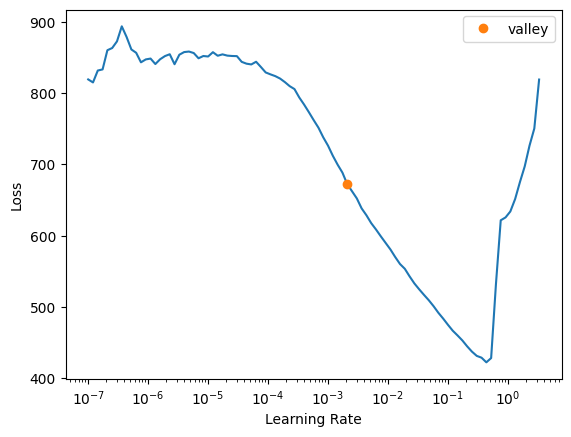

In [13]:
# Create the learner with the grade limits
learn = tabular_learner(
    dls, 
    layers=[100,50],
    metrics=rmse, 
    y_range=(0, 100)
)
suggestions = learn.lr_find()
print(f"Minimum loss divided by 10: {suggestions.valley}")

In [14]:
learn.fit_one_cycle(5, lr_max=suggestions.valley)

epoch,train_loss,valid_loss,_rmse,time
0,246.834778,119.437378,10.928741,00:00
1,91.151489,51.566082,7.180952,00:00
2,50.018536,48.138039,6.938158,00:00
3,36.420429,43.261932,6.577380,00:00
4,31.086714,43.918045,6.627069,00:00


In [16]:
learn.show_results()

<div><progress max="1" value="0"></progress> 0.00% [0/1 00:00&lt;?]</div>

,gaming_genre,gender,device_usage,stress_level,age,gaming_hours,sleep_hours,study_hours,attendance,social_activity,addiction_score,reaction_time_ms,grades,grades_pred
0,2.0,1.0,879.0,3.0,-0.389044,0.256861,-0.579883,-0.504880,-1.510901,-1.559457,0.484965,0.046040,39.930000,45.500313
1,1.0,1.0,683.0,2.0,1.545764,0.827220,1.049747,-1.564081,0.285497,-0.020769,0.614512,-1.450498,39.060001,38.893639
2,2.0,1.0,689.0,3.0,1.158803,-0.529542,0.557391,0.554320,-0.570302,-0.117369,0.024574,0.847634,87.040001,85.465469
3,2.0,2.0,835.0,3.0,-1.549929,0.118593,0.820905,-0.952704,1.224366,1.028022,-0.581308,-0.293280,65.970001,55.897667
4,2.0,2.0,833.0,2.0,-0.389044,0.663026,-0.822594,-0.824198,0.183389,0.386327,0.925426,-0.389743,41.099998,44.660057
5,1.0,1.0,519.0,2.0,1.545764,0.485869,0.592064,0.094814,-0.702695,-0.496865,0.231850,-0.655017,61.650002,68.543518
6,3.0,2.0,787.0,3.0,-1.549929,0.084026,-0.995959,-0.835881,-0.495019,-0.462366,0.333494,-0.608484,40.980000,48.924690
7,3.0,2.0,356.0,3.0,-1.549929,-1.765318,-0.753248,0.316779,0.723347,-1.097160,-0.766661,2.379835,78.099998,89.654099
8,2.0,2.0,612.0,2.0,-1.549929,0.788332,1.112159,1.399343,-1.689156,1.062522,0.732101,-0.893117,83.998894,83.450272


In [17]:
test_df = pd.read_csv('./data/test.csv')
dl = learn.dls.test_dl(test_df)
preds, _ = learn.get_preds(dl=dl)

<div><progress max="13" value="0"></progress> 0.00% [0/13 00:00&lt;?]</div>

In [25]:
# Convert predictions to a simple list of numbers
preds_list = preds.flatten().tolist() 
test_df['actual'] = test_df['grades'] # Replace with your real column name
test_df['predicted'] = preds_list
test_df['accuracy'] = 100 - abs(test_df['actual'] - test_df['predicted']) # Simple accuracy calculation

# Look at the first 10 rows
print(test_df[['actual', 'predicted', 'accuracy']].head(100))
print(f"Average Accuracy: {test_df['accuracy'].mean():.2f}%")

        actual  predicted   accuracy
0    57.286971  45.986061  88.699090
1    76.020000  74.937263  98.917263
2    42.680000  44.599968  98.080032
3    17.310000  15.942060  98.632060
4   106.774359  91.580688  84.806330
..         ...        ...        ...
95   44.964754  30.819691  85.854936
96   49.920000  58.106720  91.813280
97   42.490000  53.041111  89.448889
98   85.770000  86.802711  98.967289
99   73.530000  64.231796  90.701796

[100 rows x 3 columns]
Average Accuracy: 94.53%
